In [2]:
import numpy as np
from sim_library.simulation import simulate_pulses_p_dist, simulate_pulses_p_dist_custom, simulate_pulses_single_atom, p_shift_random_walk, simulate_optical_pumping
from sim_library.sequences import gen_resonant_pm_seq, gen_offresonant_pm_seq, UpPulse, DownPulse, FreeEvolution, PulseSequence, gen_MDFE_seq, RR3_gate, RR3short_gate
from sim_library.plotting import plot_state_trajectories, plot_bloch, plot_hist, display_table, display_table_compare
from scipy.constants import hbar, pi
from sim_library.constants import k_eff, dR, m, omega_eg, kb
import matplotlib.pyplot as plt

##### RR3 import test

In [3]:
rabi_freq = 2*pi*1e8
rabi_time = 2*pi/rabi_freq

# omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

time_steps = 1

RR3 = RR3short_gate(rabi_freq=rabi_freq, time_steps=time_steps)

p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
# initial_state[15] = 1
initial_state[16] = 1
initial_state[17] = 0
initial_state[18] = -2
initial_state[19] = 0
initial_state[20] = 3j
initial_state[21] = 0
initial_state[22] = -4j                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
initial_state[23] = 0
# initial_state[24] = 0

initial_state = initial_state/ np.linalg.norm(initial_state)

target = np.zeros(shape=len(basis), dtype=np.complex128)

target[16] = 1
target[17] = -2
target[18] = 3j
target[19] = -4j


target = target/ np.linalg.norm(target)

wave_func, times = simulate_pulses_single_atom(pulse_seq= RR3, basis= basis, initial_state=initial_state, d_shift=0)

final = wave_func[-1,:]
final = final/np.linalg.norm(final)

fidelity = np.sum(np.abs(target)*np.abs(final))**2

print(fidelity)



  
display_table_compare(basis=basis, init_state=initial_state, final_state=wave_func[-1,:])

0.9986354169797608
+---------+---------------------+------------------+----------------------+-------------------+-----------------+
|   Index |   Momentum (hbar*k) |      Initial Psi |            Final Psi |   Initial |Psi|^2 |   Final |Psi|^2 |
+=========+=====================+==================+======================+===================+=================+
|       0 |                 -16 |          0j|000> |         (-0-0j)|000> |             0     |           0     |
+---------+---------------------+------------------+----------------------+-------------------+-----------------+
|       1 |                 -15 |          0j|001> |              0j|001> |             0     |           0     |
+---------+---------------------+------------------+----------------------+-------------------+-----------------+
|       2 |                 -14 |          0j|010> |         (-0-0j)|010> |             0     |           0     |
+---------+---------------------+------------------+-----------------

##### RR3 mom dist

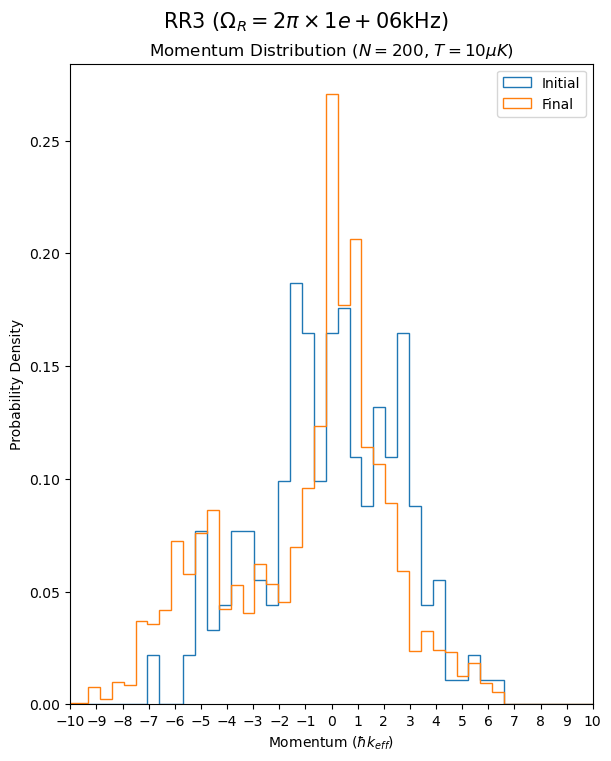

In [3]:
N = 200
Temp = 10e-6

sigma = np.sqrt(kb*Temp/m)
p_dist = np.random.normal(loc = 0, scale = sigma, size = N)*m

rabi_freq = 2*pi*1e9
rabi_time = 2*pi/rabi_freq

# omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

time_steps = 1

RR3 = RR3_gate(rabi_freq=rabi_freq, time_steps=time_steps)

p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
# initial_state[15] = 1
initial_state[16] = 1
# initial_state[17] = 0
# initial_state[18] = 1
# initial_state[19] = 0
# initial_state[20] = 1
# initial_state[21] = 0
# initial_state[22] = 1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
# initial_state[23] = 0
# initial_state[24] = 0

initial_state = initial_state/ np.linalg.norm(initial_state)

# wave_func, times = simulate_pulses_single_atom(pulse_seq= RR3, basis= basis, initial_state=initial_state, d_shift=0)

moms, fracs, mom_grid, frac_grid, _ = simulate_pulses_p_dist(pulse_seq=RR3, Temp=Temp, no_atoms=N, basis=basis, initial_state=initial_state)

moms = moms/(hbar*k_eff)

fig1, ax1 = plt.subplots(figsize=(6, 7.5), layout= 'constrained')

plot_hist(ax= ax1, mom_vals= moms, fracs= fracs, n_bins= 100, n_atoms= N, temp=Temp, contains_title= True)

fig1.suptitle(t=rf'RR3 ($\Omega_R = 2\pi\times{rabi_freq/(2*1e3*pi):.3g}$kHz)', fontsize= 15)

xlims = np.arange(-10,11)
ax1.set_xticks(xlims)
ax1.set_xlim(-10,10)

# fig1.tight_layout
plt.show()

### Optical pumping

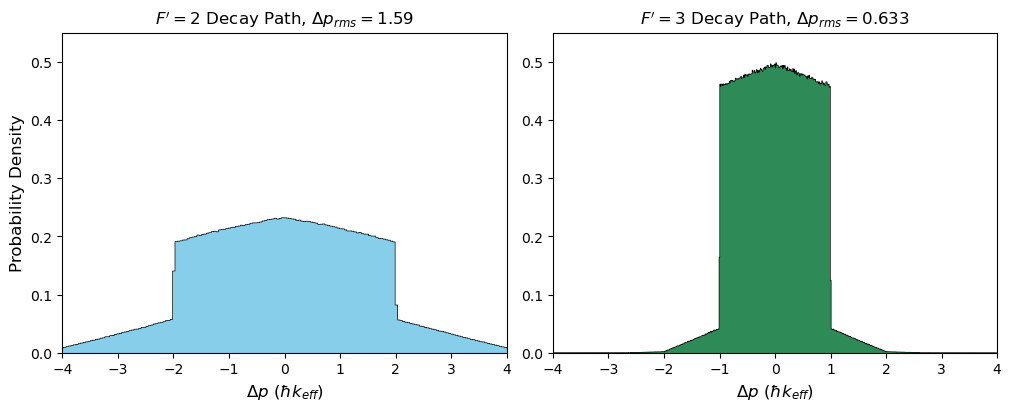

In [ ]:
# random walks
ground_state_ratio = 0.528

N = 100000000
p_dist = np.zeros(N)
n_dist = np.zeros(N)

for i in range(N):
    p, n = p_shift_random_walk(ground_state_ratio=ground_state_ratio)
    p_dist[i] = p
    n_dist[i] = n

n_photons, n_photons_counts = np.unique(n_dist, return_counts=True)
p_dist = p_dist/2

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), layout= 'constrained')

ax1.hist(x= p_dist, bins = 700, density=True, color = 'skyblue')
ax1.hist(x= p_dist, bins = 700, density=True, color = 'black', histtype='step', linewidth=0.5)
# ax2.bar(x= n_photons, height=n_photons_counts)

ax1.set_title(rf"$F'=2$ Decay Path, $\Delta p_{{rms}} =${np.sqrt(np.mean(p_dist**2)):.3g}")
ax1.set_xlabel(r'$\Delta p$ ($\hbar k_{eff}$)', fontsize = 12)
ax1.set_ylabel('Probability Density', fontsize = 12)
ax1.set_xlim(-4,4)
ax1.set_ylim(0,0.55)

# ax2.set_title(rf'Distribution of $n$ photons scattered, $\langle n\rangle =${np.mean(n_dist):.3g}')
# ax2.set_xlabel(r'$n$')
# ax2.set_ylabel(r'Frequency')
# ax2.set_xlim(0,np.max(n_dist))
# ax2.set_xticks(np.arange(n_photons[0],n_photons[-1]+1))
# random walks
ground_state_ratio = 0.831

p_dist = np.zeros(N)
n_dist = np.zeros(N)

for i in range(N):
    p, n = p_shift_random_walk(ground_state_ratio=ground_state_ratio)
    p_dist[i] = p
    n_dist[i] = n

n_photons, n_photons_counts = np.unique(n_dist, return_counts=True)
p_dist = p_dist/2



ax2.hist(x= p_dist, bins = 700, density=True, color= 'seagreen')
ax2.hist(x= p_dist, bins = 700, density=True, color= 'black',linewidth = 0.5, histtype='step')
# ax2.bar(x= n_photons, height=n_photons_counts)

ax2.set_title(rf"$F'=3$ Decay Path, $\Delta p_{{rms}} =${np.sqrt(np.mean(p_dist**2)):.3g}")
ax2.set_xlabel(r'$\Delta p$ ($\hbar k_{eff}$)', fontsize = 12)
# ax2.set_ylabel('Probability Density')
ax2.set_ylim(0,0.55)
ax2.set_xlim(-4,4)



plt.savefig(fname = 'plots/histograms/opticalpumping_confrev.png', dpi=1200, format='png', bbox_inches='tight')

(100000,)


(-8.0, 8.0)

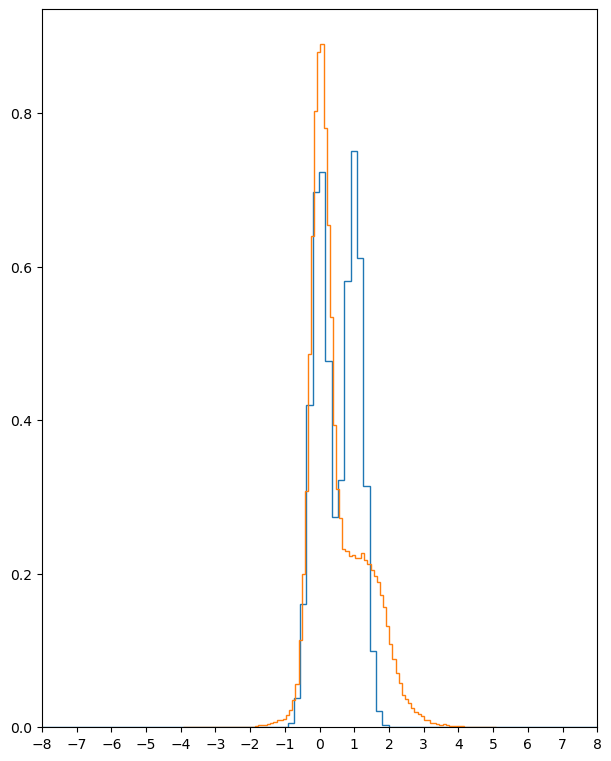

In [5]:
N = 100000
Temp = 0.1e-6

sigma = np.sqrt(kb*Temp/m)
p_dist = np.random.normal(loc = 0, scale = sigma, size = N)*m

rabi_freq = 2*pi*1e9
rabi_time = 2*pi/rabi_freq

# omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

time_steps = 1

# RR3 = RR3_gate(rabi_freq=rabi_freq, time_steps=time_steps)
dummy_pulse = FreeEvolution(laser_det=np.full(1,0), duration=1e-6)
dummy_seq = PulseSequence()
dummy_seq.add_pulses(dummy_pulse)

p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)

initial_state[8] = 1
initial_state[9] = 1

initial_state = initial_state/ np.linalg.norm(initial_state)

# wave_func, times = simulate_pulses_single_atom(pulse_seq= RR3, basis= basis, initial_state=initial_state, d_shift=0)

moms, fracs, mom_grid, frac_grid = simulate_pulses_p_dist_custom(pulse_seq=dummy_seq, init_mom_dist=p_dist, basis=basis, initial_state=initial_state)

moms = moms/(hbar*k_eff)

mom_dist2 = simulate_optical_pumping(basis=basis, init_mom_dist_grid=mom_grid, state_fracs_grid=frac_grid[-1,:,:], pumping_route='f3')
mom_dist2 = mom_dist2/(hbar*k_eff)

fig1, ax1 = plt.subplots(figsize=(6, 7.5), layout= 'constrained')

ax1.hist(x= moms, weights= fracs[0], bins = 100, histtype='step', density=True)
# ax1.hist(x= moms, weights= fracs[-1], bins = 100, histtype='step', density=True)
ax1.hist(x=mom_dist2, bins=100, histtype='step', density=True)
print(mom_dist2.shape)
# plot_hist(ax= ax1, mom_vals= moms, fracs= fracs, n_bins= 150, n_atoms= N, temp=Temp, contains_title= True)

# fig1.suptitle(t=rf'RR3 ($\Omega_R = 2\pi\times{rabi_freq/(2*1e3*pi):.3g}$kHz)', fontsize= 15)


ax1.set_xticks(basis)
ax1.set_xlim(basis[0],basis[-1])
# ax1.set_ylim(0,2)

# # fig1.tight_layout
# plt.show()